In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import pandas as pd

import sys

from glob import glob
from scipy.spatial import distance
cwd             = os.getcwd()


In [2]:
### All brain regions
CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
tab_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='plot')
tab_region = tab_region.sort_values('Order').reset_index(drop=True)
regions_all = tab_region.Area.values
region_col = tab_region.color.values

CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
all_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')

In [3]:
### all tracts
atlas_all = ['AF_L', 'AF_R', 'C_FPH_L', 'C_FPH_R', 'C_FP_L', 'C_FP_R',
       'C_PHP_L', 'C_PHP_R', 'C_PH_L', 'C_PH_R', 'C_PO_L', 'C_PO_R','EMC_L', 'EMC_R', 'FAT_L', 'FAT_R', 'IFOF_L',
       'IFOF_R', 'ILF_L', 'ILF_R','MdLF_L', 'MdLF_R', 'PAT_L',
       'PAT_R', 'SLF1_L', 'SLF1_R', 'SLF2_L', 'SLF2_R', 'SLF3_L',
       'SLF3_R', 'VOF_L', 'VOF_R']

# Remove the _L and _R suffixes and get unique labels
atlas_all = set(label[:-2] for label in atlas_all)

In [4]:
plt.rcParams.update({
    'font.family': 'arial',
    'font.size': 12,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 9,
    'svg.fonttype': 'none',
    'font.size': 10,
    'axes.titlesize': 10,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 9,
    'figure.titlesize': 10
})

In [5]:
## adding Conenctogram
path_connectogram = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram'
sys.path.append(path_connectogram)
from main_script import ConnectogramPlotter
cwp = os.getcwd()

plotter = ConnectogramPlotter()
import matplotlib.gridspec as gridspec

## functions

In [6]:
def adding_area(data_A, lbls):
    labels_all = lbls.label.values
    data_A['ChanA'] = 'Unknown'
    data_A['StimA'] = 'Unknown'
    for c in np.unique(data_A[['sc_id', 'rc_id']]).astype('int'):
        data_A.loc[data_A.rc_id == c, 'ChanA'] = " ".join(re.findall("[a-zA-Z_]+", labels_all[c]))
        data_A.loc[data_A.sc_id == c, 'StimA'] = " ".join(re.findall("[a-zA-Z_]+", labels_all[c]))
    return data_A

def adding_destrieux(data_con, area='Destrieux'):
    # area == 'Region' or 'Area'
    CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
    atlas = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')
    for subregion in np.unique(data_con[['StimA', 'ChanA']]):
        region = atlas.loc[atlas.Abbreviation == subregion, area].values
        if len(region) > 0:
            data_con.loc[data_con.StimA == subregion, 'StimD'] = region[0]
            data_con.loc[data_con.ChanA == subregion, 'ChanD'] = region[0]
        else:
            print(subregion)
            data_con.loc[data_con.StimA == subregion, 'StimD'] = 'U'
            data_con.loc[data_con.ChanA == subregion, 'ChanD'] = 'U'

    return data_con

def adding_region(data_con, area='Region'):
    # area == 'Region' or 'Area'
    CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
    atlas = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')
    for subregion in np.unique(data_con[['StimA', 'ChanA']]):
        region = atlas.loc[atlas.Abbreviation == subregion, area].values
        if len(region) > 0:
            data_con.loc[data_con.StimA == subregion, 'StimR'] = region[0]
            data_con.loc[data_con.ChanA == subregion, 'ChanR'] = region[0]
        else:
            print(subregion)
            data_con.loc[data_con.StimA == subregion, 'StimR'] = 'U'
            data_con.loc[data_con.ChanA == subregion, 'ChanR'] = 'U'

    return data_con


## 1. Load Data

In [8]:
sub_path  ='X:\\4 e-Lab\\' # y:\\eLab

In [115]:
sub_path  ='X:\\4 e-Lab\\' # y:\\eLab
filename = file_save = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', 'Across', 'Connecto', 'Data', 'labels_across.csv')
lbls_all = pd.read_csv(filename)
filename = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', 'Across', 'Connecto', 'Data', 'con_across.csv')
con_all = pd.read_csv(filename)

In [116]:
# adding unique con_id to labels and connection
lbls_all.insert(0, 'c_id', -1)
lbls_all['c_id'] = lbls_all.groupby(['Subj', 'c']).ngroup()

In [117]:
# Step 1: Merge for sc_id
con_all.rename(columns={'Stim': 'c'}, inplace=True)
con_all = con_all.merge(lbls_all[['Subj', 'c','c_id']], on=['Subj', 'c'], how='left', suffixes=('', '_sc'))
con_all.rename(columns={'c': 'Stim'}, inplace=True)
# Step 2: Rename c_id to sc_id
con_all.rename(columns={'c_id': 'sc_id'}, inplace=True)

# Step 3: Merge for rc_id
con_all.rename(columns={'Chan': 'c'}, inplace=True)
con_all = con_all.merge(lbls_all[['Subj', 'c','c_id']], on=['Subj', 'c'], how='left', suffixes=('', '_rc'))
con_all.rename(columns={'c': 'Chan'}, inplace=True)
# Step 4: Rename c_id to rc_id
con_all.rename(columns={'c_id': 'rc_id'}, inplace=True)

In [118]:
import re

In [119]:
# adding destreiux (_D) and region (R)
con_all = adding_area(con_all, lbls_all)
con_all = adding_region(con_all)
con_all = adding_destrieux(con_all, area='Destrieux')

In [120]:
con_all.loc[con_all.Sig==0, 'delay'] = np.nan
con_all.loc[con_all.Sig==0, 'Sig'] = np.nan

In [121]:
con_all= con_all[(con_all.Hemi != 'B')&(con_all.Group != 'local')&np.isin(con_all.StimR, regions_all)&np.isin(con_all.ChanR, regions_all)].reset_index(drop=True)

In [98]:
filename = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', 'Across', 'Connecto', 'Data', 'con_across_filled.csv')

con_all.to_csv(filename, header=True, index=False)

# Data Avergering

In [9]:
filename = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', 'Across', 'Connecto', 'Data', 'con_across_filled.csv')
con_all = pd.read_csv(filename)

In [146]:
# taking mean by subj and destrieux label
df_mean_subj = con_all[con_all.Sig>0].groupby(['Subj','StimA', 'ChanA','StimR', 'ChanR'], as_index=False)[['DI', 'Sig', 'delay']].mean()
#adding fake Stim  /Chan ID used for connectogram
# add unique ID to Stim column
df_mean_subj['Stim'] = df_mean_subj.groupby(['Subj', 'StimA']).ngroup()
# new table to show which StimA has which Stim ID
df_Stim_chan = df_mean_subj.groupby(['Subj','StimA'], as_index=False)['Stim'].mean()
# switch Stim to Chan
df_Stim_chan.rename(columns={'StimA': 'ChanA','Stim': 'Chan'}, inplace=True)
# merge to tables to also have a unique ID for Chan number. 
#  this way we can make sure that a label in StimA has the same Stim number as the same label in ChanA
df_mean_subj = df_mean_subj.merge(df_Stim_chan, on = ['Subj', 'ChanA'])

In [150]:
df_Stim_chan = df_mean_subj.groupby(['Subj','StimA'], as_index=False)['Stim'].mean()
df_Stim_chan

,Subj,StimA,Stim
0,EL010,CircIS_sup,0
1,EL010,CollatS_ant,1
2,EL010,HIPP,2
3,EL010,IFGtri,3
4,EL010,ITS,4
...,...,...,...
254,EL028,RostrS,254
255,EL028,SIG,255
256,EL028,STG,256
257,EL028,STS,257


In [148]:
# taking mean by subj and destrieux label
df_mean_subj = con_all[con_all.Sig>0].groupby(['Subj','StimA', 'ChanA','StimR', 'ChanR'], as_index=False)[['DI', 'Sig', 'delay']].mean()
#adding fake Stim  /Chan ID used for connectogram
# add unique ID to Stim column
df_mean_subj['Stim'] = df_mean_subj.groupby(['Subj', 'StimA']).ngroup()
df_mean_subj

,Subj,StimA,ChanA,StimR,ChanR,DI,Sig,delay,Stim
0,EL010,CircIS_sup,CollatS_ant,Insula,Basotemporal,0.225017,0.739688,0.008500,0
1,EL010,CircIS_sup,HIPP,Insula,Hippocampus,0.285581,0.436141,0.019923,0
2,EL010,CircIS_sup,IFGtri,Insula,Dorsofrontal,0.044883,0.783806,0.007867,0
3,EL010,CircIS_sup,ITS,Insula,Laterotemporal,0.220560,0.652086,0.017563,0
4,EL010,CircIS_sup,LatS_hor,Insula,Dorsofrontal,0.043500,0.890254,0.005750,0
...,...,...,...,...,...,...,...,...,...
3645,EL028,TransOrS,OrG,Orbitofrontal,Orbitofrontal,-0.154445,0.843421,0.004400,258
3646,EL028,TransOrS,RostrS,Orbitofrontal,Orbitofrontal,-0.331707,0.662726,0.000000,258
3647,EL028,TransOrS,SIG,Orbitofrontal,Insula,-0.075787,0.499820,0.007333,258
3648,EL028,TransOrS,STS,Orbitofrontal,Laterotemporal,-0.022632,0.369743,0.010368,258


In [147]:
df_mean_subj['Stim'] = df_mean_subj.groupby(['Subj', 'StimA']).ngroup()

# Plot Connectograms

In [122]:
def connectogram_region(df_plot, area = 'Amygdala'):
    fig, ax = plt.subplots(figsize=(5,5))
    plt.suptitle(area)
    df_plot['show'] = 0
    #Filtering. Show only conenction with strong directioanlity (>0.3) and involved in selected brain region
    df_plot.loc[(df_plot.DI>0.3)& ((np.isin(df_plot.StimR, area)) | (np.isin(df_plot.ChanR, area))), 'show'] = 1
    # Logic to sort and prepare df_plot
    df_plot['sort'] = 0
    df_plot['lw'] = 0.5
    df_plot.loc[np.isin(df_plot.ChanR, area), 'sort'] = 1
    df_plot = df_plot.sort_values(by=['sort']).reset_index(drop=True)

    if np.sum(df_plot.show) > 0:
        os.chdir(path_connectogram)
        plotter.load_data(df_plot, ax, 'path_save', show_label=1)
        plotter.show_plot(area + ' --  Connections', 'area')

    return fig, ax

In [129]:
def connectogram_tract(df_plot, atlas_sel = 'AF'):
    fig, ax = plt.subplots(figsize=(5,5))
    plt.suptitle(atlas_sel)
    df_plot['show'] = 0
    #Filtering. Show only conenction with strong directioanlity (>0.1) and involved in selected tract
    df_plot.loc[(df_plot.DI>0.1)&((abs(df_plot[atlas_sel+'_R'])==1)|(abs(df_plot[atlas_sel+'_L'])==1)), 'show'] = 1
    # Logic to sort and prepare df_plot
    df_plot['sort'] = 0
    df_plot['lw'] = 0.5
    df_plot = df_plot.sort_values(by=['sort']).reset_index(drop=True)

    if np.sum(df_plot.show) > 0:
        os.chdir(path_connectogram)
        plotter.load_data(df_plot, ax, 'path_save', show_label=1)
        # area to have colorcode for connection direction
        plotter.show_plot(atlas_sel + ' --  Connections', 'area')

    return fig, ax

for tracts, we can show single conenctions

In [134]:

sub_path  ='X:\\4 e-Lab\\' # y:\\eLab
filename = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', 'Across', 'Connecto', 'Data', 'con_across_filled.csv')

con_all = pd.read_csv(filename)
# all labels
filename = file_save = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', 'Across', 'Connecto', 'Data', 'labels_across.csv')
lbls_all = pd.read_csv(filename)

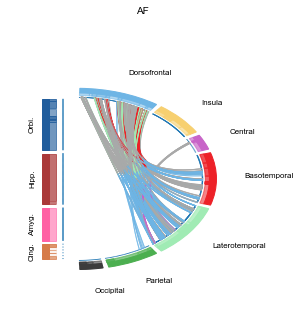

In [136]:
fig, ax = connectogram_tract(con_all, atlas_sel = 'AF')
plt.savefig('X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\BM\\ALL_BM\\AF_DI.pdf')

for regions, I suppose to show the Destrieux avarge (subject-wise) to reduce number of conenctions to visualize

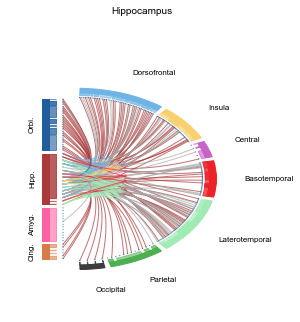

In [132]:
fig, ax = connectogram_region(df_mean_subj, area = 'Hippocampus')
plt.savefig('X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\BM\\ALL_BM\\hipp_DI.pdf')

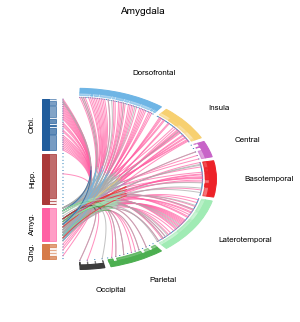

In [68]:
fig, ax = connectogram_region(df_mean_subj, area = 'Amygdala')
plt.show()

In [70]:
metric = 'NREM_effectsize'

In [107]:
sel_area = 'Amygdala'
for metric in ['DI', 'Sig']:
    
    if metric == 'DI':
        mn = np.nanmean(con_all.loc[con_all.StimR == sel_area, metric])
        st = np.nanstd(con_all.loc[con_all.StimR == sel_area, metric])
    else:
        mn = np.nanmean(con_all.loc[(con_all.Sig >0)&(con_all.StimR == sel_area), metric])
        st = np.nanstd(con_all.loc[(con_all.Sig >0)&(con_all.StimR == sel_area), metric])
    print(metric+'= {:.2f} ± {:.2f}'.format(mn, st))

DI= 0.27 ± 0.64
Sig= 0.68 ± 0.30


## Plotting by average across subjects

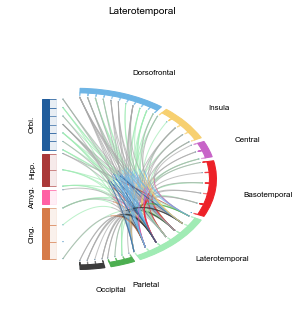

In [303]:
# taking mean by subj and destrieux label
df_mean = con_all[(con_all.Hemi!='B')].groupby(['StimA', 'ChanA','StimR', 'ChanR'], as_index=False)[['DI', 'Sig', 'delay', 'LL']].mean()

#adding fake Stim  /Chan ID used for connectogram
# df_mean['Stim'] = df_mean.groupby(['Hemi','StimA']).ngroup()
# df_Stim_chan = df_mean.groupby(['Hemi','StimA'], as_index=False)['Stim'].mean()
# df_Stim_chan.rename(columns={'StimA': 'ChanA','Stim': 'Chan'}, inplace=True)
# df_mean = df_mean.merge(df_Stim_chan, on = ['Hemi','ChanA'])
# 
# df_mean = df_mean[df_mean.Hemi != 'B'].reset_index(drop=True)

df_mean['Stim'] = df_mean.groupby(['StimA']).ngroup()
df_Stim_chan = df_mean.groupby(['StimA'], as_index=False)['Stim'].mean()
df_Stim_chan.rename(columns={'StimA': 'ChanA','Stim': 'Chan'}, inplace=True)
df_mean = df_mean.merge(df_Stim_chan, on = ['ChanA'])

df_mean= adding_region(df_mean, area='Region')
df_mean['Subj'] = 'EL000'
fig, ax = connectogram_region(df_mean, area = 'Laterotemporal')
plt.show()

### Sleep modulation

In [142]:
def connectogram_region_effectsize(df_plot, area = 'Amygdala', metric = 'LL', direction= 'incoming'):
    fig, ax = plt.subplots(figsize=(5,5))
    plt.suptitle(area + ' --  '+direction+ ' Connections')
    df_plot['show'] = 0
    #Filtering. Show only conenction with strong directioanlity (>0.3) and involved in selected brain region
    if direction == 'incoming':
        df_plot.loc[(np.isin(df_plot.ChanR, area)), 'show'] = 1
    else:
        df_plot.loc[np.isin(df_plot.StimR, area), 'show'] = 1
    # Logic to sort and prepare df_plot
    df_plot['sort'] = 0
    df_plot['lw'] = 1
    df_plot.loc[np.isin(df_plot.ChanR, area), 'sort'] = 1
    df_plot = df_plot.sort_values(by=['sort']).reset_index(drop=True)
    df_plot.loc[(df_plot[metric]>0), 'effect'] = 1
    df_plot.loc[(df_plot[metric]<0), 'effect'] = -1
    if np.sum(df_plot.show) > 0:
        os.chdir(path_connectogram)
        plotter.load_data(df_plot, ax, 'path_save', show_label=1)
        plotter.show_plot(area + ' --  '+direction+ ' Connections', 'effect')

    return fig, ax

todo: colormap specific to measurement: sleep modulation (-1:1): seismic, CCEp probability (0,1): hot /or similar. CCEP magnitude (0, ~15): autmun or similar..

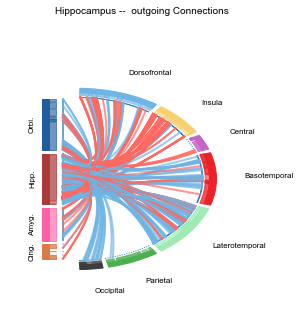

In [145]:
ss = 'NREM' # NREM or REM
con_dir = 'outgoing' # incoming or outgoing
area_sel = 'Hippocampus'

# only connection with sig. sleep modulation
data_plot = con_all[(con_all[ss+'_p']>=1)].reset_index(drop=True)

connectogram_region_effectsize(data_plot, area = area_sel, metric = ss+'_effectsize', direction= con_dir)
plt.savefig('X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\BM\\ALL_BM\\hipp_out.pdf')

In [108]:
ss = 'NREM' # NREM or REM
con_dir = 'incoming' # incoming or outgoing
area_sel = 'Amygdala'

# only connection with sig. sleep modulation
data_plot = con_all[(con_all[ss+'_p']>=1)].reset_index(drop=True)

connectogram_region_effectsize(data_plot, area = area_sel, metric = ss+'_effectsize', direction= con_dir)

NameError: name 'connectogram_region_effectsize' is not defined

(<Figure size 360x360 with 1 Axes>, <AxesSubplot:>)

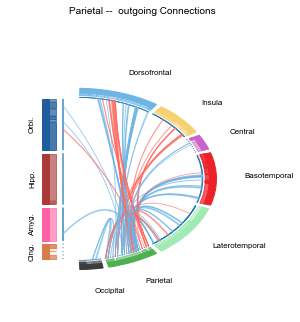

In [459]:
ss = 'NREM' # NREM or REM
con_dir = 'outgoing' # incoming or outgoing
area_sel = 'Parietal'

# only connection with sig. sleep modulation
data_plot = con_all[(con_all[ss+'_p']==1)].reset_index(drop=True)
connectogram_region_effectsize(data_plot, area = area_sel, metric = ss+'_effectsize', direction= con_dir)

# Matrix

In [10]:
con_all.loc[con_all.Sig ==0, 'LL'] = np.nan

In [11]:
# taking mean by subj and destrieux label
df_mean = con_all[(con_all.Hemi!='B')].groupby(['StimA', 'ChanA','StimR', 'ChanR'], as_index=False)[['DI', 'Sig', 'delay', 'LL']].mean()

#adding fake Stim  /Chan ID used for connectogram
# df_mean['Stim'] = df_mean.groupby(['Hemi','StimA']).ngroup()
# df_Stim_chan = df_mean.groupby(['Hemi','StimA'], as_index=False)['Stim'].mean()
# df_Stim_chan.rename(columns={'StimA': 'ChanA','Stim': 'Chan'}, inplace=True)
# df_mean = df_mean.merge(df_Stim_chan, on = ['Hemi','ChanA'])
# 
# df_mean = df_mean[df_mean.Hemi != 'B'].reset_index(drop=True)

df_mean['Stim'] = df_mean.groupby(['StimA']).ngroup()
df_Stim_chan = df_mean.groupby(['StimA'], as_index=False)['Stim'].mean()
df_Stim_chan.rename(columns={'StimA': 'ChanA','Stim': 'Chan'}, inplace=True)
df_mean = df_mean.merge(df_Stim_chan, on = ['ChanA'])
# add destrieux isntead of region
df_mean= adding_region(df_mean, area='Destrieux')
destrieux_all = np.unique(df_mean[['StimR', 'ChanR']])

load atlas label / colors

In [12]:
CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
atlas = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')
atlas.loc[atlas.Destrieux == 'entorhinal_cortex', 'Destrieux'] = 'Entorhinal'
atlas.loc[atlas.Destrieux == 'AnteroHippocampus', 'Destrieux'] = 'Hippocampus_ant'
atlas.loc[atlas.Destrieux == 'PosteroHippocampus', 'Destrieux'] = 'Hippocampus_post'
atlas = atlas[np.isin(atlas.Destrieux, destrieux_all)].reset_index(drop=True)
atlas = atlas[~np.isin(atlas.Region, ['WM', 'out', 'LV', 'necrosis'])].reset_index(drop=True)
atlas_color = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='plot')
atlas_color = atlas_color.drop(columns=['Region', 'Lobe', 'Plot']).reset_index(drop=True)
atlas_color = atlas_color.rename(columns={'Area': 'Region'})

In [13]:
# Sort labels by group
sorted_labels = atlas.sort_values(by='Region')['Destrieux']
# Map the colors to the groups in labels_groups
labels_groups = atlas.merge(atlas_color, on='Region')
# labels_groups = labels_groups[np.isin(labels_groups.Destrieux,d_atlas_labels) ].reset_index(drop=True)
labels_groups = labels_groups.drop_duplicates(subset='Destrieux', keep='first')
# Sort labels by group
sorted_labels = labels_groups.sort_values(by='Order')['Destrieux']
# Map labels to their corresponding colors
row_colors = labels_groups.set_index('Destrieux').loc[sorted_labels]['color']
col_colors = labels_groups.set_index('Destrieux').loc[sorted_labels]['color']

In [14]:
import matplotlib
# Define color values and corresponding colors
cvals  = [0, 0.1, 0.4, 0.85, 0.98]
colors = ["black","black", "firebrick", "orange", "yellow"]

# Normalize the color values to be between 0 and 1
norm = matplotlib.colors.Normalize(min(cvals), max(cvals))
norm_cvals = [norm(val) for val in cvals]

# Create tuples of normalized values and colors
tuples = list(zip(norm_cvals, colors))

# Create the colormap
cmap_sig = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

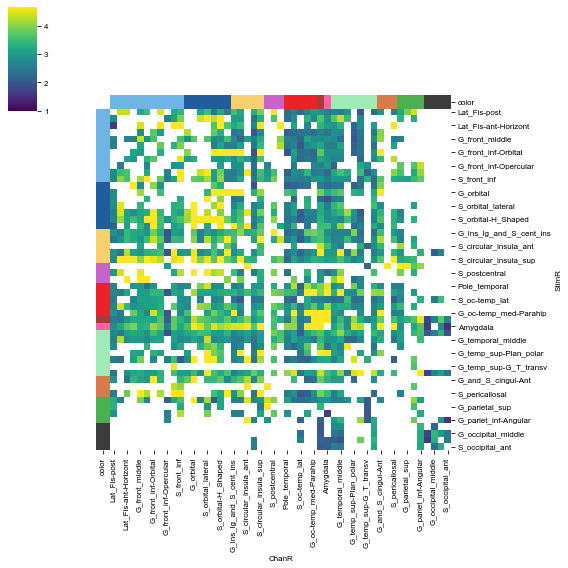

In [15]:
###Plot magnitude
metric = 'LL'
matrix_df = df_mean.pivot_table(index='StimR', columns='ChanR', values=metric)
df_sorted = matrix_df.loc[sorted_labels, sorted_labels]
# Create the heatmap without clustering
g = sns.clustermap(df_sorted, cmap='viridis',
                   row_cluster=False, col_cluster=False,
                   row_colors=row_colors, col_colors=col_colors,
                   figsize=(8,8), vmin = 1, vmax = np.nanpercentile(matrix_df.values,90))

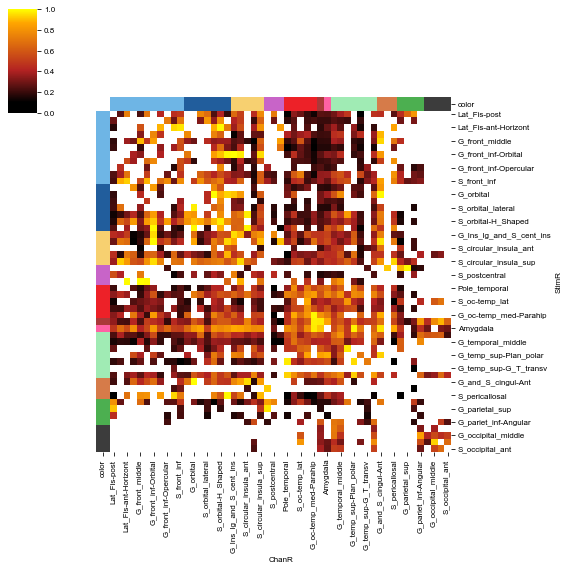

In [16]:
###Plot CCEP Probability
metric = 'Sig'
matrix_df = df_mean.pivot_table(index='StimR', columns='ChanR', values=metric)
df_sorted = matrix_df.loc[sorted_labels, sorted_labels]
# Create the heatmap without clustering
g = sns.clustermap(df_sorted, cmap=cmap_sig,
                   row_cluster=False, col_cluster=False,
                   row_colors=row_colors, col_colors=col_colors,
                   figsize=(8,8), vmin = 0)

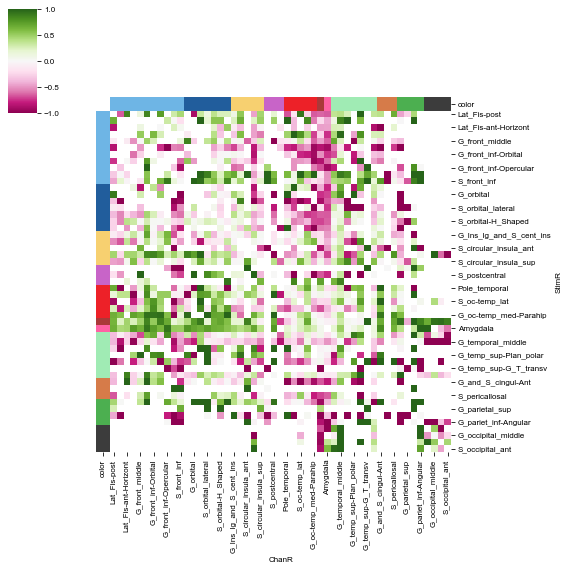

In [17]:
###Plot CCEP directionality
metric = 'DI'
matrix_df = df_mean.pivot_table(index='StimR', columns='ChanR', values=metric)
df_sorted = matrix_df.loc[sorted_labels, sorted_labels]
# Create the heatmap without clustering
g = sns.clustermap(df_sorted, cmap='PiYG',
                   row_cluster=False, col_cluster=False,
                   row_colors=row_colors, col_colors=col_colors,
                   figsize=(8,8), vmin = -1, vmax = 1)